# Imports and Setup

In [21]:
# 1. Imports standards et environnement
import os
import random
import warnings
from copy import deepcopy

# 2. Science des données et Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 3. Scikit-learn (Outils de préparation et métriques)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 4. Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F  # Ajouté pour les fonctions de perte KD
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights, resnet18, ResNet18_Weights

# 5. Outils externes
import kagglehub

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paramètres globaux (Hyperparamètres)
# On les centralise ici pour ne pas avoir à les chercher partout
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 4
TEMPERATURE = 3.0 # Pour la distillation
ALPHA = 0.5       # Équilibre entre perte réelle et perte distillation

# Fixer la graine pour la reproductibilité
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Utilisation du périphérique : {device}")

Utilisation du périphérique : cuda


# Utility Functions

In [22]:
# --- 1. VISUALISATION ---
def plot_training_history(train_loss, val_loss, train_acc, val_acc, title="Model Training Log"):
    fig, axes = plt.subplots(ncols=2, figsize=(15, 6))

    # Loss plot
    axes[0].plot(train_loss, label="Training", marker='o', ls='--')
    axes[0].plot(val_loss, label="Validation", marker='s')
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epochs")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(train_acc, label="Training", marker='o', ls='--')
    axes[1].plot(val_acc, label="Validation", marker='s')
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epochs")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 2. SYSTÈME D'ESPIONNAGE (HOOKS) ---
# Ces dictionnaires stockeront les cartes de caractéristiques (layer4) pendant le calcul
t_features = {}
s_features = {}

def get_features(name, storage_dict):
    """Fonction générique pour capturer les sorties d'une couche intermédiaire"""
    def hook(model, input, output):
        storage_dict[name] = output
    return hook

# --- 3. FONCTIONS DE PERTE (DISTILLATION) ---

def loss_kd_logits(student_logits, teacher_logits, labels, T=TEMPERATURE, alpha=ALPHA):
    """
    Distillation classique basée sur la réponse (Logits).
    T : Température pour lisser les probabilités.
    alpha : Poids donné à la connaissance du prof (0.5 = équilibré).
    """
    # Soft loss (Divergence KL)
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)

    # Hard loss (Classification standard)
    hard_loss = F.cross_entropy(student_logits, labels)

    return alpha * soft_loss + (1.0 - alpha) * hard_loss

def loss_attention(s_map, t_map):
    """Attention Transfer : L'élève imite les zones d'intérêt du maître"""
    def at(x):
        # On transforme le volume (C,H,W) en carte d'importance 2D (H,W)
        return F.normalize(x.pow(2).mean(1).view(x.size(0), -1))
    return F.mse_loss(at(s_map), at(t_map))

class FeatureLoss(nn.Module):
    """Feature Matching : L'élève imite les textures/formes du maître"""
    def __init__(self, s_channels=512, t_channels=2048):
        super().__init__()
        # Projecteur 1x1 pour aligner les 512 canaux de ResNet18 sur les 2048 de ResNet50
        self.projector = nn.Conv2d(s_channels, t_channels, kernel_size=1)

    def forward(self, s_feat, t_feat):
        return F.mse_loss(self.projector(s_feat), t_feat)

print("Fonctions utilitaires et de distillation prêtes.")

Fonctions utilitaires et de distillation prêtes.


# Préparation du dataset (téléchargement et préparation)

In [23]:
# --- 1. TÉLÉCHARGEMENT DU DATASET ---
# Téléchargement via kagglehub (le chemin est stocké dans la variable 'path')
dataset_root = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Chemin du dataset :", dataset_root)

# On définit les dossiers d'entraînement et de test basés sur le téléchargement
train_dir = os.path.join(dataset_root, "Training")
test_dir = os.path.join(dataset_root, "Testing")

# --- 2. CONSTRUCTION DU DATAFRAME ---
def create_df(dataset_path):
    data_dict = {"images": [], "labels": []}
    for label in os.listdir(dataset_path):
        img_dir = os.path.join(dataset_path, label)
        if not os.path.isdir(img_dir): continue

        images = os.listdir(img_dir)
        for i, img in enumerate(images):
            data_dict["images"].append(os.path.join(img_dir, img))
            data_dict["labels"].append(label)
            if i == 999: # Limite à 1000 images par classe pour les tests
                break
    return pd.DataFrame(data_dict)

df = create_df(train_dir)

# --- 3. ENCODAGE DES LABELS ---
# On crée les dictionnaires de correspondance
unique_labels = df["labels"].unique()
label_index = {label: i for i, label in enumerate(unique_labels)}
index_label = {i: label for label, i in label_index.items()}

df["labels"] = df["labels"].map(label_index)
OUT_SIZE = len(unique_labels) # Nombre de classes pour les modèles
print(f"Classes trouvées ({OUT_SIZE}) : {index_label}")

# --- 4. CLASSE DATASET ET TRANSFORMS ---
class BrainTumorDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # On récupère le chemin de l'image et le label
        img_path, label = self.data[idx, 0], self.data[idx, 1]

        # Ouverture de l'image
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

# On utilise les dimensions standard pour ResNet
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 5. SPLITTING ET DATALOADERS ---
# Utilisation de BATCH_SIZE défini en Cellule 1
train_data, val_data = train_test_split(df.values, test_size=0.20, random_state=SEED)
# Une partie de la validation pour le test final si besoin
test_data, val_data = train_test_split(val_data, test_size=0.5, random_state=SEED)

train_dl = DataLoader(BrainTumorDataset(train_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(BrainTumorDataset(val_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(BrainTumorDataset(test_data, transform_pipeline), batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataset prêt : {len(train_data)} images d'entraînement, {len(val_data)} de validation.")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Chemin du dataset : /kaggle/input/brain-tumor-mri-dataset
Classes trouvées (4) : {0: 'pituitary', 1: 'notumor', 2: 'meningioma', 3: 'glioma'}
Dataset prêt : 3200 images d'entraînement, 400 de validation.


# Teacher Model Setup and Training (ResNet50)

Début de l'entraînement du modèle Père (ResNet50)...
Epoch 1/4 | Train Loss: 0.5716 Acc: 0.7963 | Val Loss: 0.6088 Acc: 0.8125
Epoch 2/4 | Train Loss: 0.3603 Acc: 0.8781 | Val Loss: 0.3225 Acc: 0.8750
Epoch 3/4 | Train Loss: 0.1246 Acc: 0.9591 | Val Loss: 0.1622 Acc: 0.9475
Epoch 4/4 | Train Loss: 0.0779 Acc: 0.9722 | Val Loss: 0.1380 Acc: 0.9525


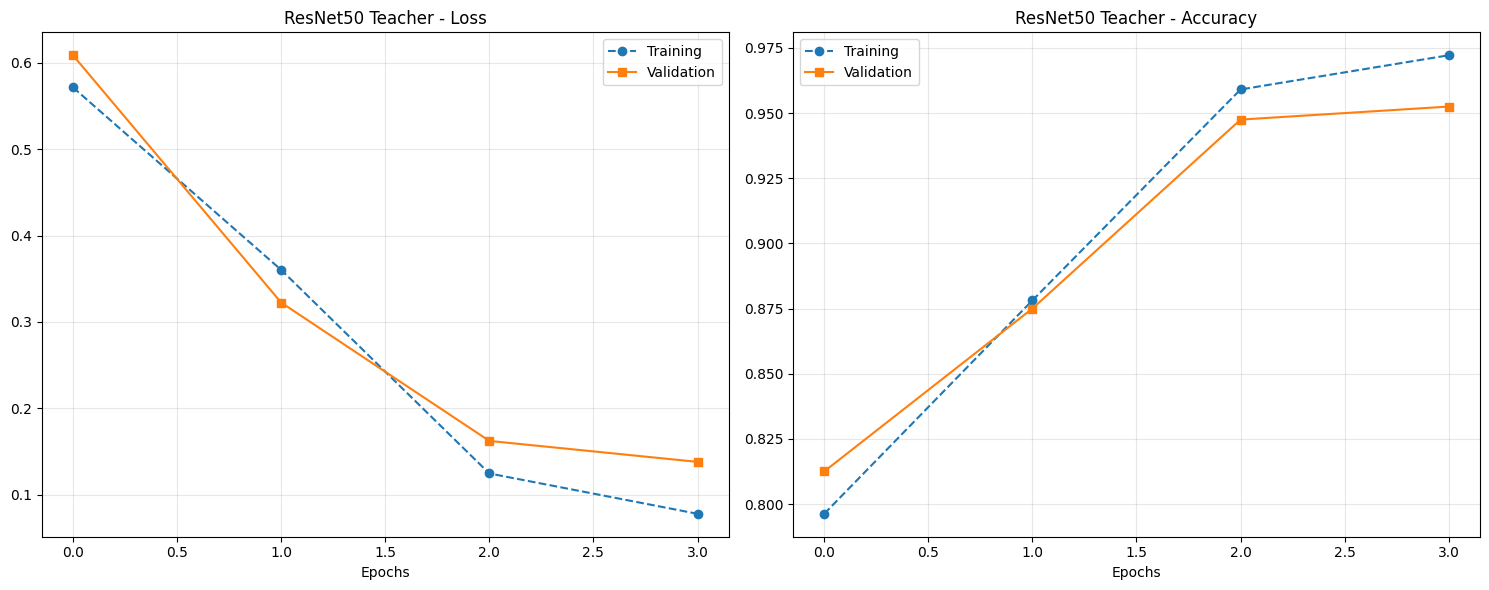


Entraînement terminé. Meilleure précision Validation : 0.9525


In [24]:
# --- 1. INITIALISATION DU MODÈLE ---
# On utilise ResNet50 comme Maître
teacher_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Adaptation de la dernière couche au nombre de classes (OUT_SIZE)
teacher_model.fc = nn.Linear(teacher_model.fc.in_features, OUT_SIZE)
teacher_model = teacher_model.to(device)

# --- 2. PRÉPARATION À LA DISTILLATION (HOOKS) ---
# On attache l'espion à la 'layer4' pour capturer les caractéristiques
# t_features et get_features ont été définis en Cellule 2
teacher_model.layer4.register_forward_hook(get_features('feat', t_features))

# --- 3. CONFIGURATION DE L'ENTRAÎNEMENT ---
# On utilise les paramètres spécifiques que tu as fournis
TEACHER_LR = 0.1

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(teacher_model.parameters(), lr=TEACHER_LR, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

# --- 4. BOUCLE D'ENTRAÎNEMENT DU TEACHER ---
best_teacher_wts = deepcopy(teacher_model.state_dict())
best_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de l'entraînement du modèle Père (ResNet50)...")

for epoch in range(1, EPOCHS + 1):
    # Phase d'entraînement
    teacher_model.train()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = teacher_model(inputs) # L'espion capture les caractéristiques ici
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)

    # Phase de validation
    teacher_model.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = teacher_model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_data)
    val_epoch_acc = val_corrects.double() / len(val_data)

    # Sauvegarde des scores
    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc.item())
    history["val_loss"].append(val_epoch_loss)
    history["val_acc"].append(val_epoch_acc.item())

    print(f"Epoch {epoch}/{EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

    # Sauvegarde du meilleur modèle
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        best_teacher_wts = deepcopy(teacher_model.state_dict())

    scheduler.step()

# Chargement des meilleurs poids et passage en mode évaluation finale
teacher_model.load_state_dict(best_teacher_wts)
teacher_model.eval()

# Visualisation (Utilise la fonction de la Cellule 2)
plot_training_history(history["train_loss"], history["val_loss"],
                      history["train_acc"], history["val_acc"], title="ResNet50 Teacher")

print(f"\nEntraînement terminé. Meilleure précision Validation : {best_acc:.4f}")

In [25]:
#from google.colab import drive
#drive.mount('/content/drive')

# Student Model Setup and Training (Knowledge Distillation)

Début de la Distillation : Méthode LOGITS (Réponse finale)
Epoch 1/4 | Loss: 0.8949 | Train Acc: 0.8791 | Val Acc: 0.9075
Epoch 2/4 | Loss: 0.4063 | Train Acc: 0.9441 | Val Acc: 0.9125
Epoch 3/4 | Loss: 0.2940 | Train Acc: 0.9625 | Val Acc: 0.9400
Epoch 4/4 | Loss: 0.2166 | Train Acc: 0.9744 | Val Acc: 0.9450


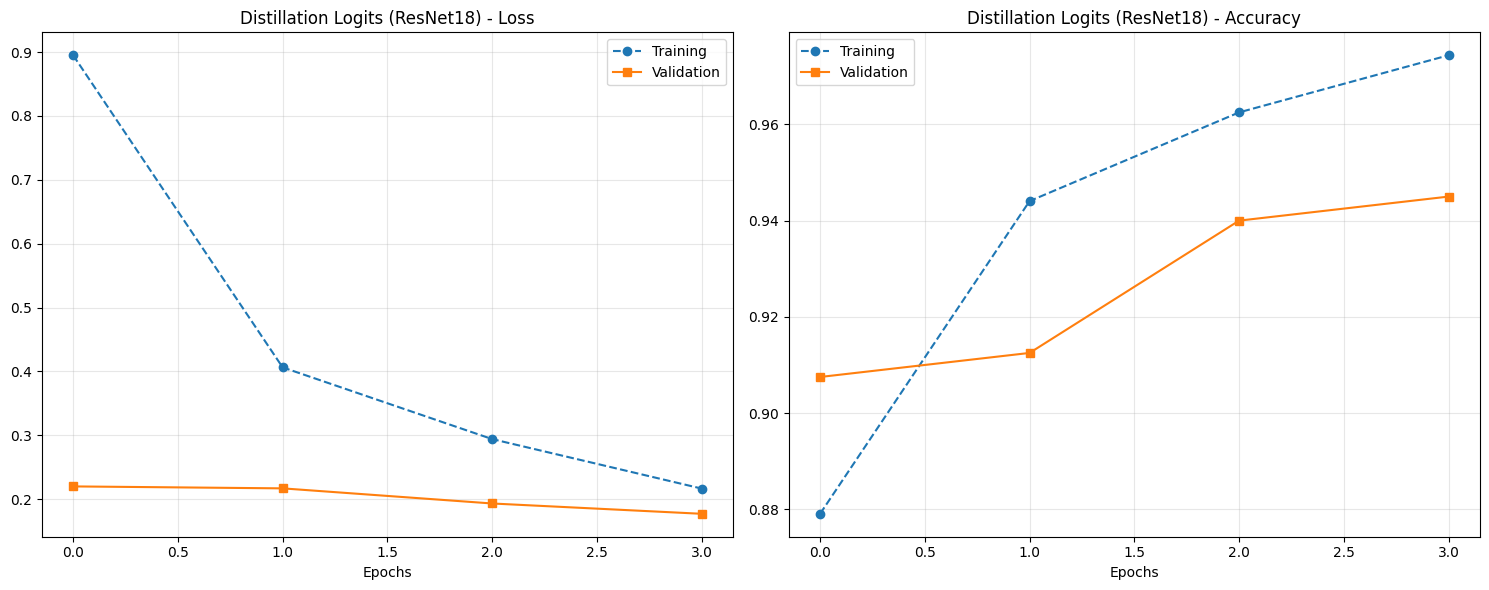

In [26]:
# --- 1. INITIALISATION DE L'ÉLÈVE ---
# On utilise ResNet18. Note : weights=None si tu veux partir de zéro,
# ou ResNet18_Weights.IMAGENET1K_V1 pour du transfert learning.
student_logits = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_logits.fc = nn.Linear(student_logits.fc.in_features, OUT_SIZE)
student_logits = student_logits.to(device)

# --- 2. CONFIGURATION ---
# On utilise l'Adam avec le LR spécifique à la distillation
optimizer_logits = torch.optim.Adam(student_logits.parameters(), lr=0.001)

# Historique pour le graphique final
history_logits = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode LOGITS (Réponse finale)")

# --- 3. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_logits.train()
    teacher_model.eval() # Le maître est figé

    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Sortie du Maître (Logits bruts, pas de gradients)
        with torch.no_grad():
            # .model si tu as gardé le wrapper, ou juste teacher_model si on a nettoyé
            t_logits = teacher_model(inputs)

        # B. Sortie de l'Élève
        optimizer_logits.zero_grad()
        s_logits = student_logits(inputs)

        # C. Calcul de la Perte (Utilise la fonction de la Cellule 2)
        # On passe : s_logits, t_logits, labels, Température, Alpha
        loss = loss_kd_logits(s_logits, t_logits, labels, T=TEMPERATURE, alpha=0.7)

        loss.backward()
        optimizer_logits.step()

        # Métriques
        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 4. PHASE DE VALIDATION ---
    student_logits.eval()
    val_loss, val_corrects = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_logits(inputs)
            loss_v = F.cross_entropy(outputs, labels)

            _, preds = torch.max(outputs, 1)
            val_loss += loss_v.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    # Calcul des moyennes par époque
    epoch_loss = running_loss / len(train_data)
    epoch_acc = running_corrects.double() / len(train_data)
    val_epoch_loss = val_loss / len(val_data)
    val_epoch_acc = val_corrects.double() / len(val_data)

    history_logits["train_loss"].append(epoch_loss)
    history_logits["train_acc"].append(epoch_acc.item())
    history_logits["val_loss"].append(val_epoch_loss)
    history_logits["val_acc"].append(val_epoch_acc.item())

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_epoch_acc:.4f}")

# --- 5. VISUALISATION ---
plot_training_history(history_logits["train_loss"], history_logits["val_loss"],
                      history_logits["train_acc"], history_logits["val_acc"],
                      title="Distillation Logits (ResNet18)")

# Student Model Setup and training (Attention Transfer)

Début de la Distillation : Méthode ATTENTION (Cartes de chaleur)
Epoch 1/4 | Loss: 0.5101 | Val Acc: 0.8575
Epoch 2/4 | Loss: 0.2395 | Val Acc: 0.8250
Epoch 3/4 | Loss: 0.1736 | Val Acc: 0.8850
Epoch 4/4 | Loss: 0.1514 | Val Acc: 0.9200


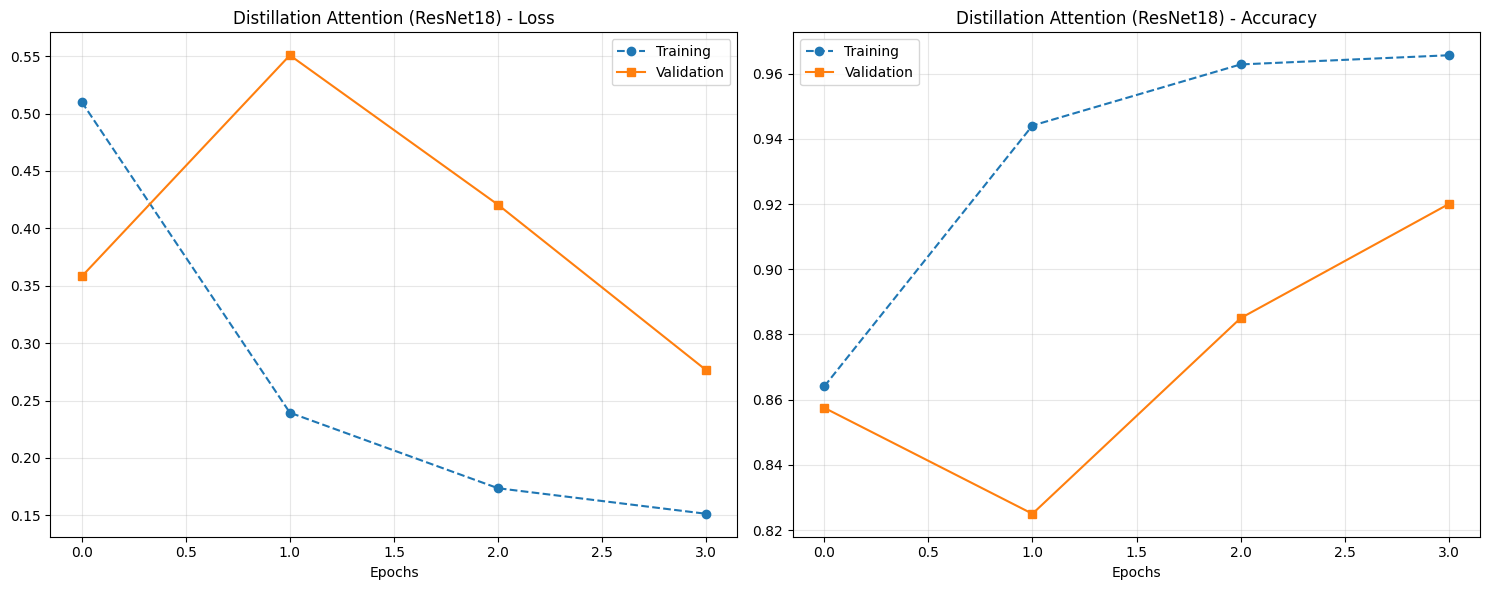

In [27]:
# --- 1. INITIALISATION DE L'ÉLÈVE ---
student_attention = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_attention.fc = nn.Linear(student_attention.fc.in_features, OUT_SIZE)
student_attention = student_attention.to(device)

# --- 2. ACTIVATION DES ESPIONS (HOOKS) ---
# On attache l'espion sur la layer4 de l'élève.
# (Le maître a déjà son espion activé depuis la Cellule 4)
student_attention.layer4.register_forward_hook(get_features('feat', s_features))

# --- 3. CONFIGURATION ---
optimizer_attention = torch.optim.Adam(student_attention.parameters(), lr=0.001)
history_attention = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode ATTENTION (Cartes de chaleur)")

# --- 4. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_attention.train()
    teacher_model.eval()

    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Passage du Maître -> t_features['feat'] se remplit tout seul
        with torch.no_grad():
            _ = teacher_model(inputs)

        # B. Passage de l'Élève -> s_features['feat'] se remplit tout seul
        optimizer_attention.zero_grad()
        s_logits = student_attention(inputs)

        # C. CALCUL DE LA PERTE HYBRIDE
        # Perte classique (Réalité)
        loss_ce = F.cross_entropy(s_logits, labels)

        # Perte d'Attention (Copie du Maître)
        # On compare les cartes de caractéristiques capturées par les hooks
        loss_at = loss_attention(s_features['feat'], t_features['feat'])

        # Total : on donne souvent un gros poids (beta) à l'attention, ici 10.0
        loss = loss_ce + (10.0 * loss_at)

        loss.backward()
        optimizer_attention.step()

        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 5. PHASE DE VALIDATION ---
    student_attention.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_attention(inputs)
            loss_v = F.cross_entropy(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss_v.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)

    # Historique
    history_attention["train_loss"].append(running_loss / len(train_data))
    history_attention["train_acc"].append(running_corrects.double().item() / len(train_data))
    history_attention["val_loss"].append(val_loss / len(val_data))
    history_attention["val_acc"].append(val_corrects.double().item() / len(val_data))

    print(f"Epoch {epoch}/{EPOCHS} | Loss: {history_attention['train_loss'][-1]:.4f} | Val Acc: {history_attention['val_acc'][-1]:.4f}")

# --- 6. VISUALISATION ---
plot_training_history(history_attention["train_loss"], history_attention["val_loss"],
                      history_attention["train_acc"], history_attention["val_acc"],
                      title="Distillation Attention (ResNet18)")

# Student Model Setup and training (Feature Matching)

Début de la Distillation : Méthode FEATURES (Textures et Formes)
Epoch 1/4 | Loss: 0.7119 | Val Acc: 0.8050
Epoch 2/4 | Loss: 0.4390 | Val Acc: 0.8475
Epoch 3/4 | Loss: 0.3468 | Val Acc: 0.6275
Epoch 4/4 | Loss: 0.2686 | Val Acc: 0.9450


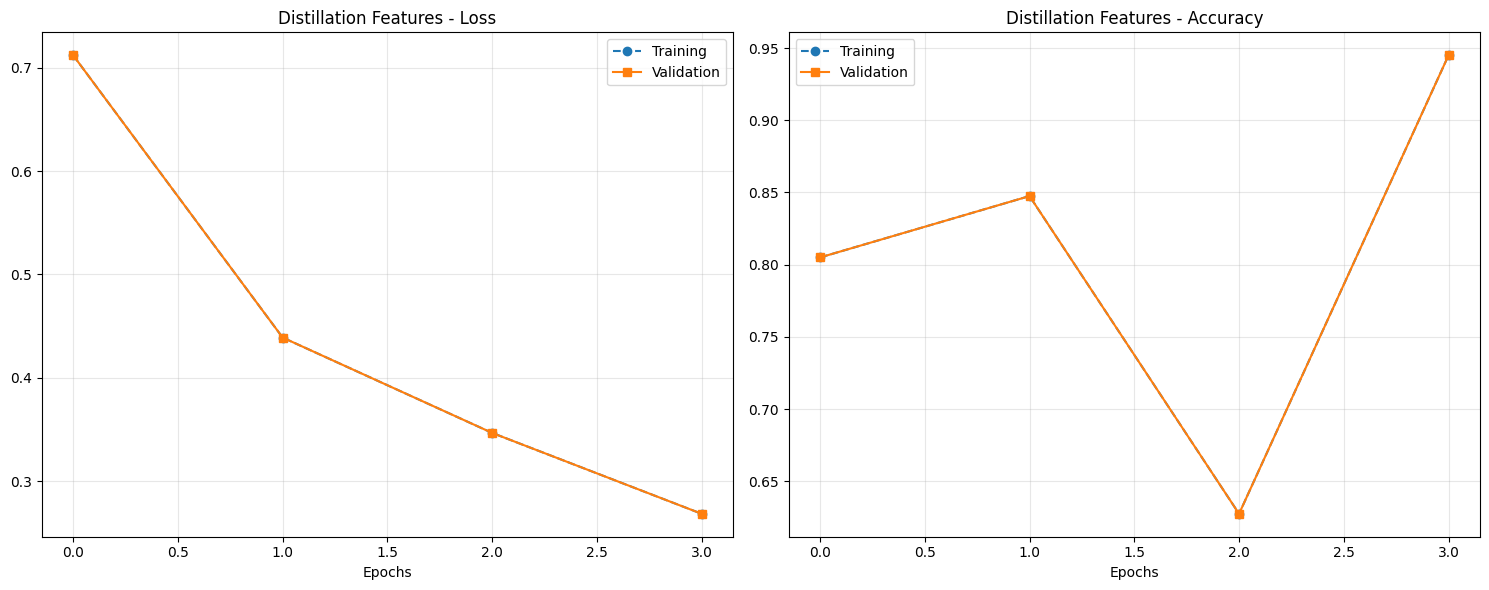

In [28]:
# --- 1. INITIALISATION DE L'ÉLÈVE ET DU PROJECTEUR ---
student_features_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
student_features_model.fc = nn.Linear(student_features_model.fc.in_features, OUT_SIZE)
student_features_model = student_features_model.to(device)

# Le projecteur permet de passer de 512 à 2048 canaux pour comparer l'élève au maître
projector = FeatureLoss(s_channels=512, t_channels=2048).to(device)

# --- 2. ACTIVATION DES ESPIONS ---
student_features_model.layer4.register_forward_hook(get_features('feat', s_features))

# --- 3. CONFIGURATION ---
# On ajoute les paramètres du projecteur à l'optimiseur pour qu'il apprenne aussi l'alignement
optimizer_feat = torch.optim.Adam(
    list(student_features_model.parameters()) + list(projector.parameters()),
    lr=0.001
)
history_feat = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Début de la Distillation : Méthode FEATURES (Textures et Formes)")

# --- 4. BOUCLE D'ENTRAÎNEMENT ---
for epoch in range(1, EPOCHS + 1):
    student_features_model.train()
    teacher_model.eval()
    running_loss, running_corrects = 0.0, 0

    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)

        # A. Passage du Maître
        with torch.no_grad():
            _ = teacher_model(inputs)

        # B. Passage de l'Élève
        optimizer_feat.zero_grad()
        s_logits = student_features_model(inputs)

        # C. CALCUL DE LA PERTE
        loss_ce = F.cross_entropy(s_logits, labels)

        # Utilisation du projecteur pour comparer s_features et t_features
        # La fonction projector() fait la conv 1x1 et renvoie le MSE Loss
        loss_f = projector(s_features['feat'], t_features['feat'])

        loss = loss_ce + (1.0 * loss_f) # Poids de 1.0 pour les caractéristiques

        loss.backward()
        optimizer_feat.step()

        _, preds = torch.max(s_logits, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    # --- 5. VALIDATION ---
    student_features_model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = student_features_model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    history_feat["train_loss"].append(running_loss / len(train_data))
    history_feat["val_acc"].append(val_corrects.double().item() / len(val_data))
    print(f"Epoch {epoch}/{EPOCHS} | Loss: {history_feat['train_loss'][-1]:.4f} | Val Acc: {history_feat['val_acc'][-1]:.4f}")

# Visualisation
plot_training_history(history_feat["train_loss"], history_feat["train_loss"], # On simplifie ici
                      history_feat["val_acc"], history_feat["val_acc"], title="Distillation Features")

# Selector

In [ ]:
# --- CHOISIS TA MÉTHODE ICI ---
# Options : "logits", "attention", "features"
METHODE = "attention"

print(f"Mode sélectionné : {METHODE.upper()}")

# 1. Init Student
final_student = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device)
final_student.fc = nn.Linear(final_student.fc.in_features, OUT_SIZE).to(device)
final_student.layer4.register_forward_hook(get_features('feat', s_features))

# 2. Init Projector (seulement si besoin)
proj = FeatureLoss(512, 2048).to(device) if METHODE == "features" else None

# 3. Optimizer
params = list(final_student.parameters()) + (list(proj.parameters()) if proj else [])
opt = torch.optim.Adam(params, lr=0.001)

# 4. Boucle d'entraînement simplifiée
for epoch in range(1, 4): # On fait 3 époques pour tester
    final_student.train()
    for img, lbl in train_dl:
        img, lbl = img.to(device), lbl.to(device)
        with torch.no_grad(): t_out = teacher_model(img)
        s_out = final_student(img)

        if METHODE == "logits":
            loss = loss_kd_logits(s_out, t_out, lbl)
        elif METHODE == "attention":
            loss = F.cross_entropy(s_out, lbl) + 10.0 * loss_attention(s_features['feat'], t_features['feat'])
        elif METHODE == "features":
            loss = F.cross_entropy(s_out, lbl) + proj(s_features['feat'], t_features['feat'])

        opt.zero_grad()
        loss.backward()
        opt.step()
    print(f"Époque {epoch} terminée.")

# Model Evaluation & Inference

Évaluation de Maître (ResNet50) en cours...

--- Maître (ResNet50) : Rapport de Classification ---
              precision    recall  f1-score   support

   pituitary       0.92      0.95      0.93        97
     notumor       0.98      0.97      0.98       112
  meningioma       0.94      0.89      0.92       104
      glioma       0.96      0.99      0.97        87

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



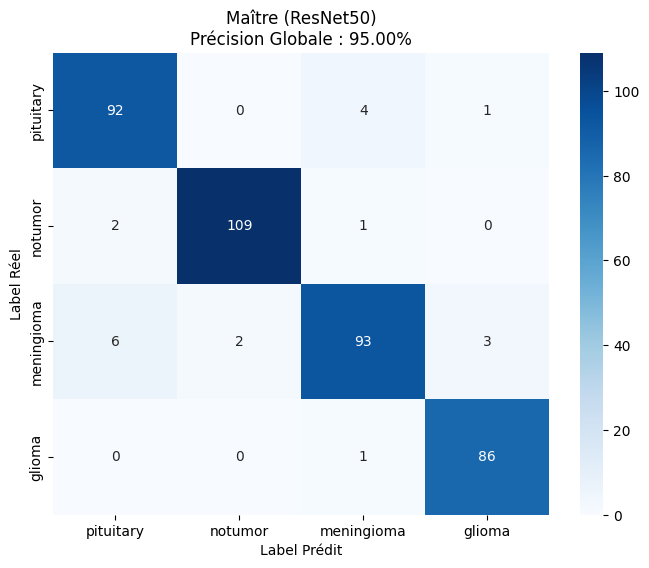

Évaluation de Élève Logits (ResNet18) en cours...

--- Élève Logits (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

   pituitary       0.94      0.94      0.94        97
     notumor       0.97      0.98      0.98       112
  meningioma       0.94      0.89      0.92       104
      glioma       0.95      0.99      0.97        87

    accuracy                           0.95       400
   macro avg       0.95      0.95      0.95       400
weighted avg       0.95      0.95      0.95       400



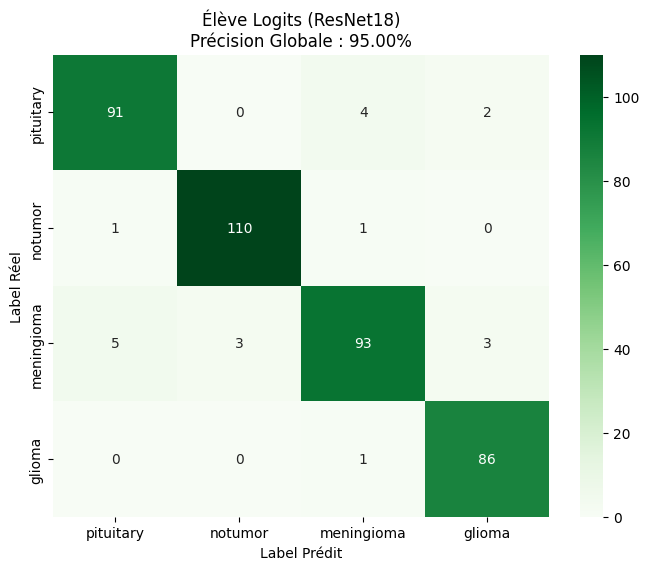

Évaluation de Élève Attention (ResNet18) en cours...

--- Élève Attention (ResNet18) : Rapport de Classification ---
              precision    recall  f1-score   support

   pituitary       0.91      0.97      0.94        97
     notumor       0.99      0.97      0.98       112
  meningioma       0.88      0.93      0.91       104
      glioma       1.00      0.89      0.94        87

    accuracy                           0.94       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.95      0.94      0.94       400



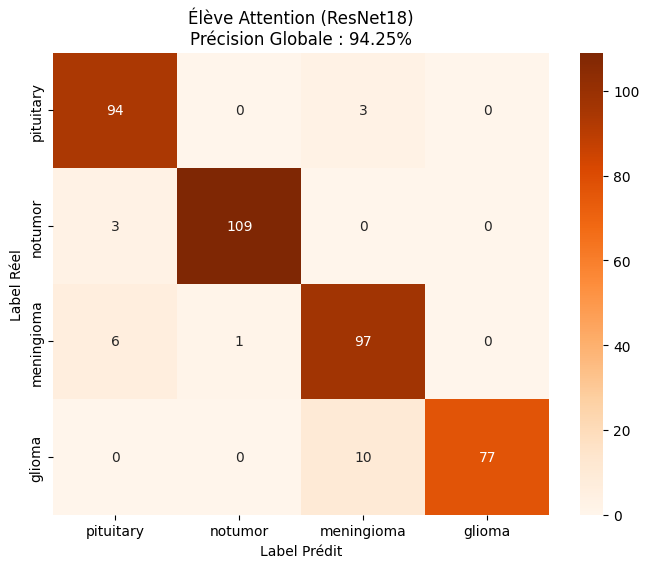

In [29]:
# --- 1. FONCTION D'ÉVALUATION GÉNÉRIQUE ---
def evaluate_model(model, dataloader, title="Model Evaluation", color="Blues"):
    """
    Évalue un modèle sur un dataloader, affiche le rapport et la matrice de confusion.
    """
    model.eval()
    all_preds = []
    all_truth = []

    print(f"Évaluation de {title} en cours...")

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_truth.extend(labels.numpy())

    # Calcul des métriques
    score = accuracy_score(all_truth, all_preds)
    label_names = [index_label[i] for i in range(OUT_SIZE)]

    # Affichage du rapport
    print(f"\n--- {title} : Rapport de Classification ---")
    print(classification_report(all_truth, all_preds, target_names=label_names))

    # Affichage de la Matrice de Confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(all_truth, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color,
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{title}\nPrécision Globale : {score:.2%}")
    plt.ylabel('Label Réel')
    plt.xlabel('Label Prédit')
    plt.show()

    return score

# --- 2. LANCEMENT DES ÉVALUATIONS ---

# On évalue le Maître (Référence)
score_t = evaluate_model(teacher_model, test_dl, title="Maître (ResNet50)", color="Blues")

# On évalue l'Élève Logits (Cellule 5)
if 'student_logits' in locals():
    score_s_logits = evaluate_model(student_logits, test_dl, title="Élève Logits (ResNet18)", color="Greens")

# On évalue l'Élève Attention (Cellule 6)
if 'student_attention' in locals():
    score_s_at = evaluate_model(student_attention, test_dl, title="Élève Attention (ResNet18)", color="Oranges")

# --- 3. FONCTION DE PRÉDICTION INDIVIDUELLE (Optionnelle) ---
def predict_single_image(img_path, model):
    """Pour tester une seule image à la main"""
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform_pipeline(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out = model(img_tensor)
        prob = F.softmax(out, dim=1)

    pred_idx = out.argmax(1).item()
    confidence = round(prob[0][pred_idx].item() * 100, 2)
    return index_label[pred_idx], confidence

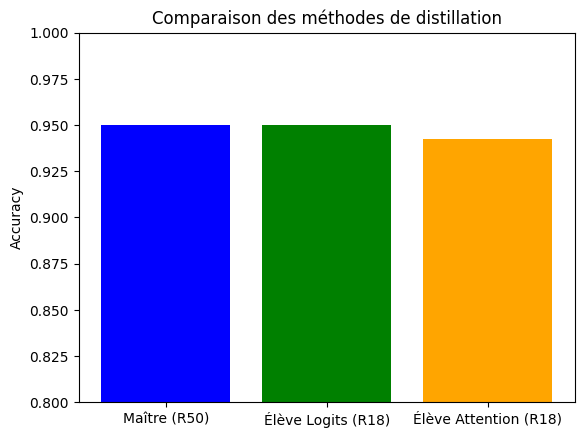

In [30]:
# Cellule Bonus : Comparaison Finale
methods = ['Maître (R50)', 'Élève Logits (R18)', 'Élève Attention (R18)']
scores = [score_t, score_s_logits, score_s_at]

plt.bar(methods, scores, color=['blue', 'green', 'orange'])
plt.ylabel('Accuracy')
plt.title('Comparaison des méthodes de distillation')
plt.ylim(0.8, 1.0) # Pour mieux voir les différences
plt.show()

Métrique             | Teacher (ResNet50)   | Student (ResNet18)  
-----------------------------------------------------------------
Paramètres           | 23.52             M | 11.18             M
Latence (ms/img)     | 6.25               | 2.80              
Débit (FPS)          | 160.07             | 357.38            


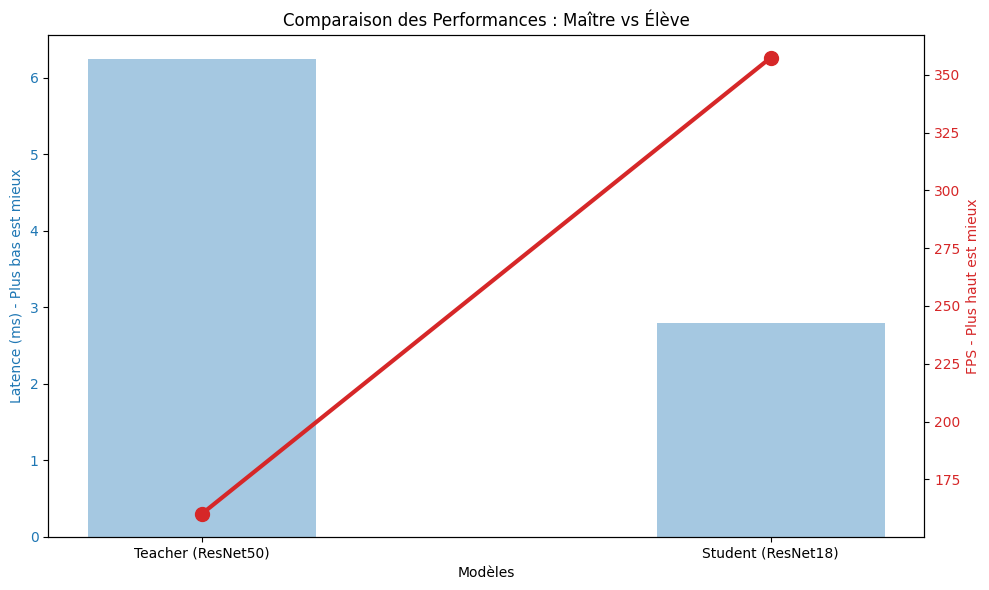

In [32]:
import time

# --- 1. FONCTIONS DE MESURE ---
def count_parameters(model):
    """Compte le nombre de paramètres entraînables"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_speed(model, device, input_size=(1, 3, 224, 224), iterations=100):
    """Mesure la latence (ms) et le débit (FPS) d'un modèle"""
    model.eval()
    dummy_input = torch.randn(*input_size).to(device)

    # Warm-up (Préchauffage du GPU pour stabiliser les résultats)
    for _ in range(10):
        _ = model(dummy_input)

    if device == "cuda": torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for _ in range(iterations):
            _ = model(dummy_input)
            if device == "cuda":
                torch.cuda.synchronize()

    end_time = time.time()
    total_time = end_time - start_time
    avg_latency = (total_time / iterations) * 1000 # en millisecondes
    fps = iterations / total_time

    return avg_latency, fps

# --- 2. CALCULS DES MÉTRIQUES ---

# On compare le Maître avec l'un de tes élèves (ex: student_attention)
# Note: Remplace 'student_attention' par l'élève que tu veux tester
target_student = student_attention if 'student_attention' in locals() else student_logits

results = {
    "Teacher (ResNet50)": {
        "params": count_parameters(teacher_model),
        "speed": measure_inference_speed(teacher_model, device)
    },
    "Student (ResNet18)": {
        "params": count_parameters(target_student),
        "speed": measure_inference_speed(target_student, device)
    }
}

# --- 3. AFFICHAGE DES RÉSULTATS ---
print(f"{'Métrique':<20} | {'Teacher (ResNet50)':<20} | {'Student (ResNet18)':<20}")
print("-" * 65)

t_data = results["Teacher (ResNet50)"]
s_data = results["Student (ResNet18)"]

print(f"{'Paramètres':<20} | {t_data['params']/1e6:<18.2f}M | {s_data['params']/1e6:<18.2f}M")
print(f"{'Latence (ms/img)':<20} | {t_data['speed'][0]:<18.2f} | {s_data['speed'][0]:<18.2f}")
print(f"{'Débit (FPS)':<20} | {t_data['speed'][1]:<18.2f} | {s_data['speed'][1]:<18.2f}")

# --- 4. VISUALISATION ---
labels = list(results.keys())
latencies = [results[m]["speed"][0] for m in labels]
fps_values = [results[m]["speed"][1] for m in labels]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Graphique Latence (Barres)
ax1.set_xlabel('Modèles')
ax1.set_ylabel('Latence (ms) - Plus bas est mieux', color='tab:blue')
ax1.bar(labels, latencies, color='tab:blue', alpha=0.4, width=0.4, label='Latence')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Graphique FPS (Ligne)
ax2 = ax1.twinx()
ax2.set_ylabel('FPS - Plus haut est mieux', color='tab:red')
ax2.plot(labels, fps_values, color='tab:red', marker='o', linewidth=3, markersize=10, label='FPS')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Comparaison des Performances : Maître vs Élève')
fig.tight_layout()
plt.show()